In [90]:
import seaborn as sns 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = sns.load_dataset("iris")
print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


## Task 1

### Task 1.1


In [91]:
print("Số dòng là:", df.shape[0])
print("Số cột là:", df.shape[1])
print("Kiểu dữ liệu của từng cột:")
print(df.dtypes)

Số dòng là: 150
Số cột là: 5
Kiểu dữ liệu của từng cột:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


### Task 1.2


In [92]:
dang_so= df.select_dtypes(include = 'number')
thong_tin= pd.DataFrame({
    "Mean": dang_so.mean(),
    "Median": dang_so.median(),
    "Mode": dang_so.mode().iloc[0],
    "Var": dang_so.var(),
    "Std": dang_so.std(),
    "Min" : dang_so.min(),
    "Max" : dang_so.max(),
    "Q1" : dang_so.quantile(0.25),
    "Q3": dang_so.quantile(0.75),
})
thong_tin["IQR"]= thong_tin["Q3"] - thong_tin["Q1"]
print(thong_tin.T)

        sepal_length  sepal_width  petal_length  petal_width
Mean        5.843333     3.057333      3.758000     1.199333
Median      5.800000     3.000000      4.350000     1.300000
Mode        5.000000     3.000000      1.400000     0.200000
Var         0.685694     0.189979      3.116278     0.581006
Std         0.828066     0.435866      1.765298     0.762238
Min         4.300000     2.000000      1.000000     0.100000
Max         7.900000     4.400000      6.900000     2.500000
Q1          5.100000     2.800000      1.600000     0.300000
Q3          6.400000     3.300000      5.100000     1.800000
IQR         1.300000     0.500000      3.500000     1.500000


### Task 1.3

In [93]:
nhom_thongtin = (
    df.groupby("species", observed= True).agg(["mean", "std"]
    )
)
print(nhom_thongtin.T)


species              setosa  versicolor  virginica
sepal_length mean  5.006000    5.936000   6.588000
             std   0.352490    0.516171   0.635880
sepal_width  mean  3.428000    2.770000   2.974000
             std   0.379064    0.313798   0.322497
petal_length mean  1.462000    4.260000   5.552000
             std   0.173664    0.469911   0.551895
petal_width  mean  0.246000    1.326000   2.026000
             std   0.105386    0.197753   0.274650


### Nhận xét:
- Qua quan sát ta thấy loài setose khác biệt nhất bởi ở 3 thông số sepal_length,petal_length,petal_length là nhỏ nhất và sepal_width là lớn nhất. Đồng thời dữ liệu của loài setosa được phân phối khá đồng đều bởi có std nhỏ ở 3 biến số.

## Task 2

### Task 2.1

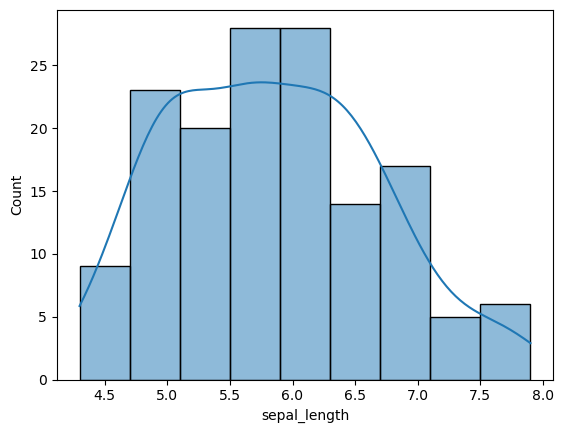

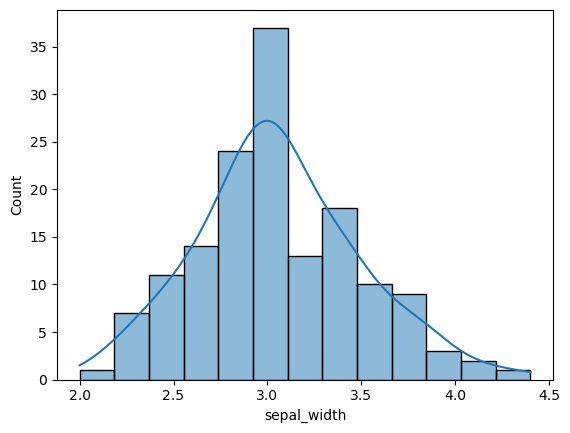

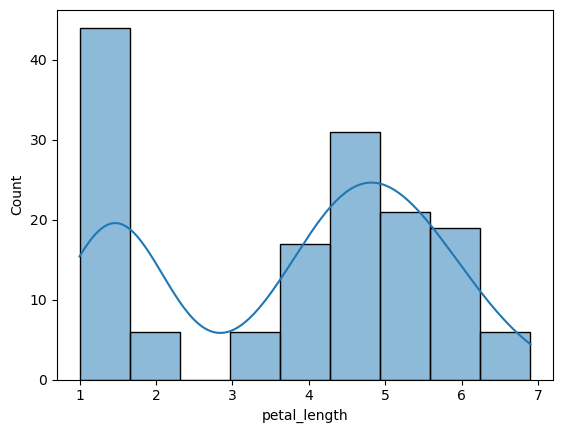

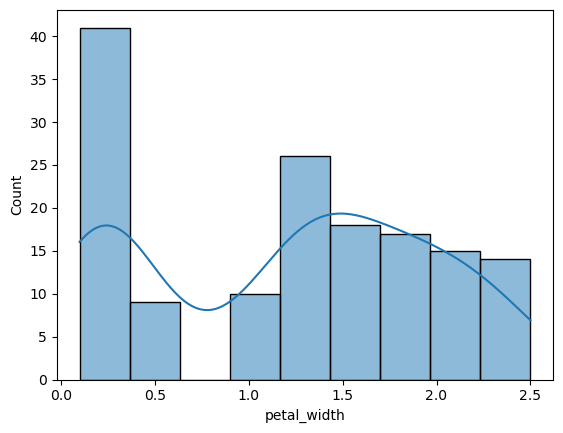

In [94]:
histogram_sepal_length = sns.histplot(data = df, x = "sepal_length",kde = True)
plt.show(histogram_sepal_length)
histogram_sepal_width = sns.histplot(data = df, x = "sepal_width",kde = True)
plt.show(histogram_sepal_width)
histogram_petal_length = sns.histplot(data = df, x = "petal_length",kde = True)
plt.show(histogram_petal_length)
histogram_petal_width = sns.histplot(data = df, x = "petal_width",kde = True)
plt.show(histogram_petal_width)

### Nhận xét:
- Với biến sepal_length: đường KDE đối xứng  gần với phân phối chuẩn
- Với biến sepal_width: đường KDE lệch phải
- với biến petal_length và petal_width: có đa đỉnh 

### Task 2.2

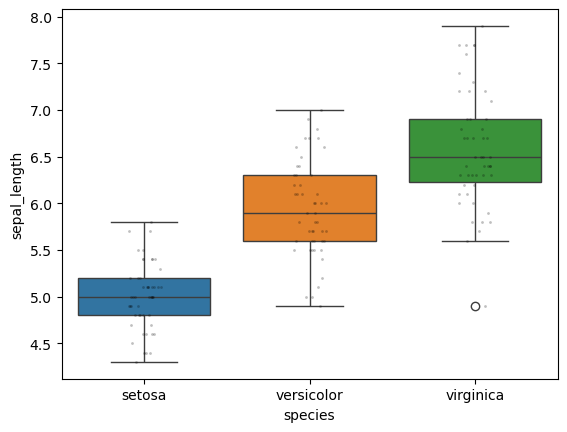

In [95]:
sns.boxplot(data = df, x = "species" , y = "sepal_length", hue= "species", legend = False);
sns.stripplot(data= df, x = "species", y = "sepal_length", color = "black", size =2 , alpha = 0.25);


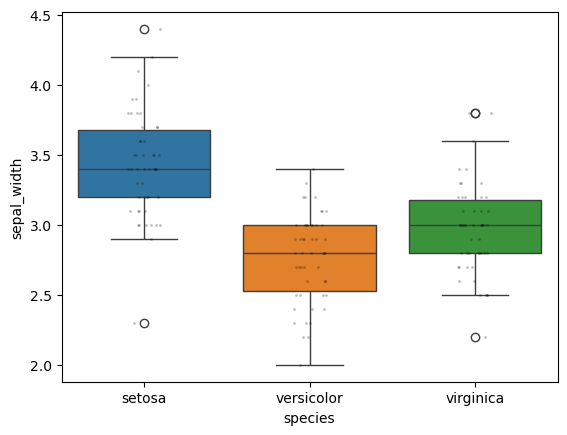

In [96]:
sns.boxplot(data = df, x = "species" , y = "sepal_width", hue= "species", legend = False);
sns.stripplot(data= df, x = "species", y = "sepal_width", color = "black", size =2 , alpha = 0.25);


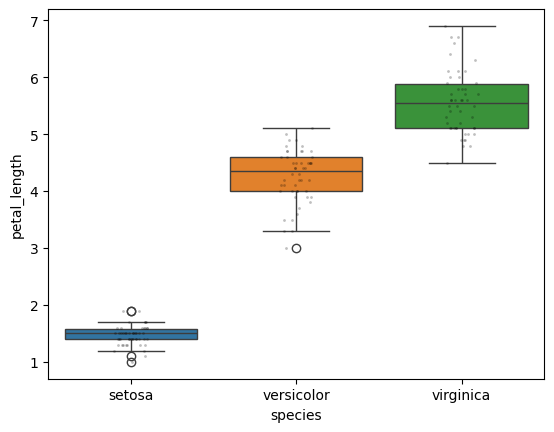

In [97]:
sns.boxplot(data = df, x = "species" , y = "petal_length", hue= "species", legend = False);
sns.stripplot(data= df, x = "species", y = "petal_length", color = "black", size =2 , alpha = 0.25);

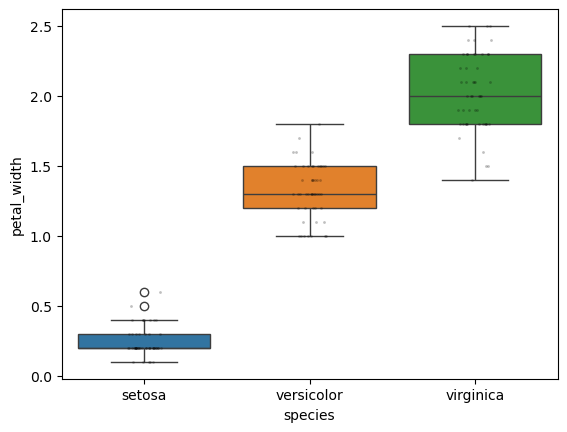

In [98]:
sns.boxplot(data = df, x = "species" , y = "petal_width", hue= "species", legend = False);
sns.stripplot(data= df, x = "species", y = "petal_width", color = "black", size =2 , alpha = 0.25);

### Task 2.3

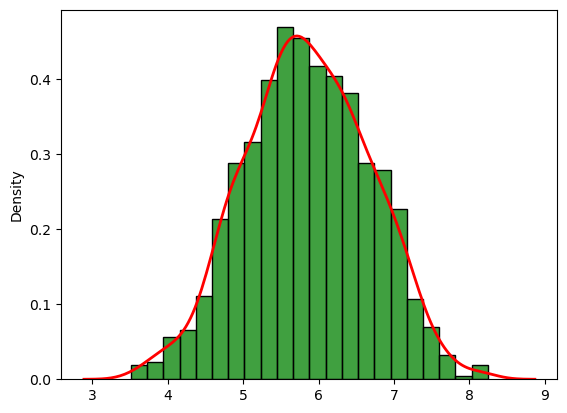

In [99]:
bien_so = df['sepal_length']
mean_bienso = bien_so.mean()
std_bienso = bien_so.std()

random_bienso = np.random.normal(mean_bienso, std_bienso, 1000)

sns.histplot(data = random_bienso, stat ="density", color = "green", bins= 22 , label = "Dữ liệu thực tế");
sns.kdeplot(data= random_bienso, color = "red", linewidth = 2, label = "Đường cong PDF lý thuyết" );

### Nhận xét:
- Dữ liệu thực tế của biến sepal_length bám khá sát với đường PDF lý thuyết.
- Đỉnh của giá trị thực tế và đỉnh của đường lý thuyết gần trùng nhau.
- Ở 2 bên đuổi giá trị thực tế và đường cong lý thuyết thoải đều, giảm dần khá giồng nhau 

## Task 3

### Task 3.1

In [100]:
df_num = df.select_dtypes(include = 'number')
cov = df_num.cov()
print("Ma trận hiệp phương sai")
print(cov)
corr = df_num.corr()
print("Ma trận tương quan")
print(corr)


Ma trận hiệp phương sai
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006
Ma trận tương quan
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


### task 3.2

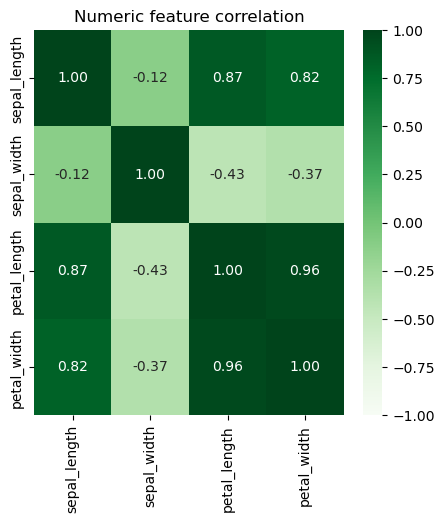

In [101]:
fig, ax= plt.subplots(figsize = (5,5))
sns.heatmap(corr, annot = True , fmt = ".2f" , cmap = "Greens" , vmin =-1 , vmax = 1, ax= ax)
ax.set_title("Numeric feature correlation")
plt.show()

### Task 3.3

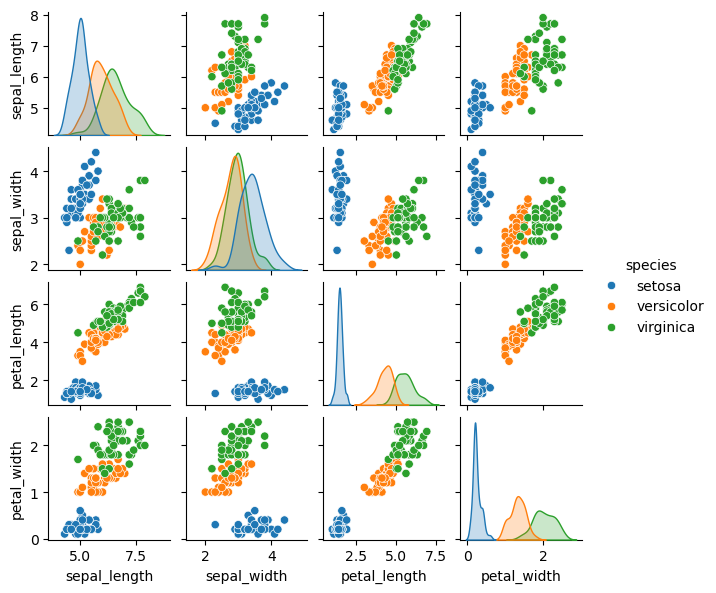

In [102]:

sns.pairplot(df, hue = "species", height = 1.5);

### Nhận xét:
#### 1. Sự phân tách của các loài
* Loài `setosa` nằm tách biệt so với 2 loài còn lại trong hầu hết các biểu đồ phân tán.
* Loài `versicolor` và `virginica` nằm gần nhau và có một số vùng dữ liệu chồng lên nhau 
#### 2. Mối tương quan
- Tuyến tính rất mạnh: cặp `petal_length` và `petal_width` có mối tương quan mạnh, khi `petal_length` tăng thì `petal_width` tăng theo tỉ lệ rất đều.
- Tuyến tính mạnh: `sepal_length` và 2 cặp `petal_length` và `petal_width`.
#### 3. Hình dạng phân phối đơn biến (Đường chéo chính)
* Biến `petal_length` và `petal_width` của loài `setosa` có phân phối dạng đỉnh nhọn, hẹp và tập trung, chứng tỏ kích thước cánh hoa của loài này rất đồng đều.
* Phân phối tổng thể của các biến (nếu không chia theo loài) sẽ có dạng nhiều đỉnh do sự khác biệt lớn về kích cỡ giữa nhóm `setosa` và hai nhóm còn lại.

## Task 4

### Task 4.1

In [103]:
P_B = 0.01
P_pos_B = 0.99
P_pos_NB = 0.05
P_pos = P_pos_B *P_B + P_pos_NB*(1-P_pos_NB)
P_B_pos = P_pos_B *P_B /P_pos
print(round(P_B_pos, 4))

0.1725


### Task 4.2

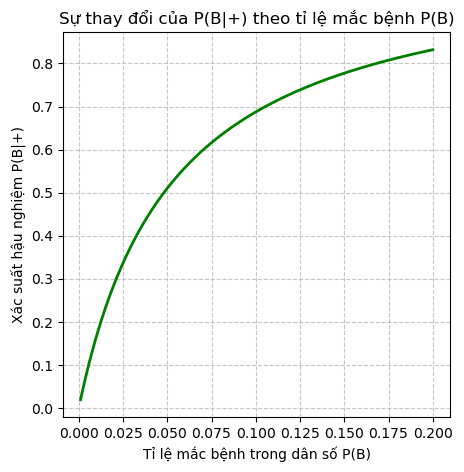

In [104]:
arrayB = np.linspace(0.001, 0.2, 1000)
arraypos = (P_pos_B*arrayB)+(P_pos_NB*(1-arrayB))
arrayB_pos= (P_pos_B*arrayB)/arraypos

plt.subplots(figsize =(5,5))
plt.plot(arrayB, arrayB_pos, color ='green', linewidth= 2)
plt.title('Sự thay đổi của P(B|+) theo tỉ lệ mắc bệnh P(B)')
plt.xlabel('Tỉ lệ mắc bệnh trong dân số P(B)')
plt.ylabel('Xác suất hậu nghiệm P(B|+)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Nhận xét:
- Nếu tỉ lệ mắc bệnh P(B)= 0,001 rất thấp trong một quần thể nhiều người khỏe mạnh, thì tỉ lệ dương tính giả 5% là cực kì lớn trong quần thể đó, lớn hơn nhiều so với dương tính thật.
- Vậy nên phần lớn xét nghiệm dương tính đối với bệnh hiếm gặp cho ra kết quả không đúng, tạo ra hiện tượng "phản trực giác".